### 데이터 병합: 일별배출농도+일정기상정보+월별발전실적

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [31]:
df1=pd.read_csv('./기상정보_전처리후.csv')
df2=pd.read_csv('./발전실적_호기전처리후.csv')
df3=pd.read_csv('./일평균대기오염물질배출농도_호기전처리후.csv')
df4 = pd.read_excel('./한국남동발전_기상정보(일평균).xls') # 원본 데이터
df5 = pd.read_csv('./기상정보.csv', encoding='cp949') # 여수 데이터 합친 데이터


## 발전실적 원본 데이터 (df2)

In [12]:
df2.head(3)

,사업소,호기,일자,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,연도,월,new_호기,호기구분
0,경상대태양광,1,2024-12-01,0.91,78.62,0.0,11.61,태양력,기타,2024,12,1,NaN
1,고흥만 수상태양광,1,2024-12-01,63.48,6026.18,0.0,12.76,태양력,기타,2024,12,1,NaN
2,광양항세방태양광,1,2024-12-01,3.10,204.02,0.0,8.85,태양력,기타,2024,12,1,NaN


In [15]:
df2['사업소'].unique()

array(['경상대태양광', '고흥만 수상태양광', '광양항세방태양광', '구미태양광', '군위 화산풍력', '두산태양광',
       '분당', '분당연료전지', '삼천포', '삼천포태양광', '삼천포태양광#5', '삼천포태양광#6', '삼천포풍력',
       '삼천포해양소수력', '안산연료전지', '어음풍력', '여수', '여수연료전지', '여수태양광', '영동',
       '영동태양광', '영흥', '영흥태양광', '영흥태양광 #3', '영흥태양광#5', '영흥풍력', '영흥해양소수력',
       '예천태양광', '탑선태양광'], dtype=object)

In [22]:
target_사업소 = ['분당', '분당연료전지', '삼천포', '여수', '여수연료전지', '영동','영흥']
df2_final = df2[df2['사업소'].isin(target_사업소)]


In [28]:
df2_final.head()

,사업소,호기,일자,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,연도,월,new_호기,호기구분
6,분당,CG1,2024-12-01,77.76,52698.0,30.85,91.09,복합,분당,2024,12,1,CG
7,분당,CG2,2024-12-01,77.76,26642.0,30.50,46.05,복합,분당,2024,12,2,CG
8,분당,CG3,2024-12-01,77.76,63329.0,31.96,109.46,복합,분당,2024,12,3,CG
9,분당,CG4,2024-12-01,77.76,2407.0,31.10,4.16,복합,분당,2024,12,4,CG
10,분당,CG5,2024-12-01,77.76,38057.0,21.41,65.78,복합,분당,2024,12,5,CG


In [25]:
df2_final['일자'] = pd.to_datetime(df2_final['일자'])
missing_date(df2_final)

<ipython-input-25-e9205eb1148c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_final['일자'] = pd.to_datetime(df2_final['일자'])


        지역   호기  누락일자수                                               누락일자
0       분당  CG1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
1       분당  CG2    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
2       분당  CG3    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
3       분당  CG4    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
4       분당  CG5    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
5       분당  CG6    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
6       분당  CG7    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
7       분당  CG8    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
8       분당  CS1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
9       분당  CS2    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
10  분당연료전지    2    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
11  분당연료전지    3    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
12  분당연료전지    4    707  DatetimeIndex(

## NOX 원본 데이터(df3)

In [52]:
df3['일자'] = pd.to_datetime(df3['날짜'])
df3.head(3)


,사업소,호기,일자,SOX,NOX,먼지,산소,유량,온도,연도,월,일,날짜,new_호기,호기구분,연월
0,분당,1호기,2024-12-31,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,31,2024-12-31,1,NaN,2024-12
1,분당,2호기,2024-12-31,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,31,2024-12-31,2,NaN,2024-12
2,분당,3호기,2024-12-31,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,31,2024-12-31,3,NaN,2024-12


In [ ]:
missing_date(df3)
# 분당 2, 4, 6, 7, 8호기 누락일자에 발전 X
# 영동(2023-01-30)은 결측치 맞음
# 영흥은 1,2호기 발전 X, 3-6호기 결측치임 (해당 날짜에 발전실적 있음)


     지역    호기  누락일자수                                               누락일자
0    분당   1호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
1    분당   2호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
2    분당   3호기      4  DatetimeIndex(['2023-04-02', '2023-12-13', '20...
3    분당   4호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
4    분당   5호기      5  DatetimeIndex(['2023-03-14', '2023-03-15', '20...
5    분당   6호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
6    분당   7호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
7    분당   8호기      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
8   삼천포  5A호기     14  DatetimeIndex(['2023-10-11', '2023-10-12', '20...
9   삼천포  5B호기     14  DatetimeIndex(['2023-10-11', '2023-10-12', '20...
10  삼천포  6A호기     27  DatetimeIndex(['2023-10-11', '2023-10-12', '20...
11  삼천포  6B호기     14  DatetimeIndex(['2023-10-11', '2023-10-12', '20...
12   영동   1호기      1  DatetimeIndex(['2023-01-30'], dtype='datet

,지역,호기,누락일자수,누락일자
0,분당,1호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
1,분당,2호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
2,분당,3호기,4,"DatetimeIndex(['2023-04-02', '2023-12-13', '20..."
3,분당,4호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
4,분당,5호기,5,"DatetimeIndex(['2023-03-14', '2023-03-15', '20..."
5,분당,6호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
6,분당,7호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
7,분당,8호기,3,"DatetimeIndex(['2023-12-13', '2023-12-14', '20..."
8,삼천포,5A호기,14,"DatetimeIndex(['2023-10-11', '2023-10-12', '20..."
9,삼천포,5B호기,14,"DatetimeIndex(['2023-10-11', '2023-10-12', '20..."


In [11]:
missing_date(df2)

           지역 호기  누락일자수                                               누락일자
0      경상대태양광  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
1   고흥만 수상태양광  1    715  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
2    광양항세방태양광  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
3       구미태양광  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
4     군위 화산풍력  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
..        ... ..    ...                                                ...
59    영흥해양소수력  2    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
60    영흥해양소수력  3    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
61      예천태양광  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
62      탑선태양광  1    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...
63      탑선태양광  3    707  DatetimeIndex(['2023-01-02', '2023-01-03', '20...

[64 rows x 4 columns]


### 누락일자 보간

In [ ]:
# 1. 영흥 + 선재도 데이터 추출
sunjae_mask = (df4['사업소'] == '영흥') & (df4['호기'] == '선재도')
df_sunjae = df4.loc[sunjae_mask].copy()
df_sunjae['일자'] = pd.to_datetime(df_sunjae['일자'], format='%Y%m%d')

# 2. 전체 날짜 생성
full_dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

# 3. 누락된 날짜 보간을 위한 재인덱싱
df_sunjae = df_sunjae.set_index('일자').reindex(full_dates)

# 4. 고정 정보 입력
df_sunjae['사업소'] = '영흥'
df_sunjae['호기'] = '선재도'

# 5. 강수량 보간
df_sunjae['강수량'] = df_sunjae['강수량'].interpolate(method='time')

# 6. 일자 컬럼 복원
df_sunjae = df_sunjae.reset_index().rename(columns={'index': '일자'})

# 7. 원본 df에서 영흥 + 선재도 행 제거
df4 = df4[~(df4['사업소'] == '영흥')]

# 9. 보간된 선재도 데이터 추가
df4 = pd.concat([df4, df_sunjae], ignore_index=True)

# 10. 정렬
df4 = df4.sort_values(by=['사업소', '호기', '일자']).reset_index(drop=True)


### 영흥 결측치 처리 완료
df4[df4['사업소'] == '영흥'].head()

## 기상정보 원본 데이터 (df4)

In [32]:
df4 = pd.read_excel('./한국남동발전_기상정보(일평균).xls')
df4['일자'] = pd.to_datetime(df4['일자'], format='%Y%m%d')
df4.head(3)

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,-,2024-12-31,-3.77,66.45,333.13,2.52,NaN,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
1,영동,-,2024-12-31,1.60,27.90,261.88,2.54,0.0,1016.0,1.60,27.90,261.88,2.54,0.0,1016.0
2,영흥,내2리,2024-12-31,-2.34,69.76,296.44,0.85,NaN,NaN,-2.34,69.76,296.44,0.85,NaN,NaN


In [219]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4984 entries, 0 to 4983
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   사업소     4984 non-null   object        
 1   호기      4984 non-null   object        
 2   일자      4984 non-null   datetime64[ns]
 3   온도      4983 non-null   float64       
 4   습도      4983 non-null   float64       
 5   풍향      4983 non-null   float64       
 6   풍속      4983 non-null   float64       
 7   강수량     1869 non-null   float64       
 8   기압      668 non-null    float64       
 9   대기안정도   4983 non-null   float64       
 10  증발량     4983 non-null   float64       
 11  일조시간    4983 non-null   float64       
 12  전일강수량   4983 non-null   float64       
 13  60분강수량  1869 non-null   float64       
 14  금일강수량   668 non-null    float64       
dtypes: datetime64[ns](1), float64(12), object(2)
memory usage: 584.2+ KB


#### 누락 일자 함수 (missing_date)

In [38]:
import pandas as pd

def missing_date(df_name):
    # 일자 컬럼이 datetime 형식인지 확인하고 변환
    df = df_name.copy()
    df['일자'] = pd.to_datetime(df['일자'])

    # 결과 저장용 리스트
    missing_date_info = []

    # 사업소 + 호기 조합별로 그룹화
    for (plant, unit), group in df.groupby(['사업소', '호기']):
        # 일자 기준 정렬
        group = group.sort_values('일자')

        # 전체 날짜 범위 생성 (빈 날짜 포함)
        full_range = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

        # 누락된 날짜 확인
        missing_dates = full_range.difference(group['일자'])

        if len(missing_dates) > 0:
            missing_date_info.append({
                '지역': plant,
                '호기': unit,
                '누락일자수': len(missing_dates),
                '누락일자': missing_dates
            })

    # 결과 DataFrame으로 변환
    missing_df = pd.DataFrame(missing_date_info)

    print(missing_df)
    return missing_df


In [41]:
missing_df = missing_date(df4)

    지역   호기  누락일자수                                               누락일자
0   분당    -      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
1  삼천포    -    128  DatetimeIndex(['2023-02-17', '2023-02-18', '20...
2   영동    -     62  DatetimeIndex(['2023-01-30', '2023-06-06', '20...
3   영흥  내2리    126  DatetimeIndex(['2023-01-21', '2023-06-03', '20...
4   영흥  내6리    122  DatetimeIndex(['2023-01-21', '2023-06-03', '20...
5   영흥  선재도    133  DatetimeIndex(['2023-01-21', '2023-04-08', '20...
6   영흥  외1리    163  DatetimeIndex(['2023-01-21', '2023-06-03', '20...
7   영흥  외3리    127  DatetimeIndex(['2023-01-21', '2023-06-03', '20...


In [50]:
yd = missing_df[missing_df['지역'] == '영동']
yd['누락일자']

2    DatetimeIndex(['2023-01-30', '2023-06-06', '20...
Name: 누락일자, dtype: object

### 영흥 데이터 보간 (선재도 데이터 사용)

In [30]:
df = df4.copy()
df['일자'] = pd.to_datetime(df['일자'])

# 결과 저장용 리스트
missing_date_info = []

# 사업소 + 호기 조합별로 그룹화
for (plant, unit), group in df.groupby(['사업소', '호기']):
    # 일자 기준 정렬
    group = group.sort_values('일자')

    # 전체 날짜 범위 생성 (빈 날짜 포함)
    full_range = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

    # 누락된 날짜 확인
    missing_dates = full_range.difference(group['일자'])

    if len(missing_dates) > 0:
        missing_date_info.append({
            '지역': plant,
            '호기': unit,
            '누락일자수': len(missing_dates),
            '누락일자': missing_dates
        })

# 결과 DataFrame으로 변환
missing_df = pd.DataFrame(missing_date_info)
print(missing_df)

    지역   호기  누락일자수                                               누락일자
0   분당    -    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
1  삼천포    -    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
2   영동    -    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
3   영흥  내2리    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
4   영흥  내6리    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
5   영흥  선재도    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
6   영흥  외1리    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...
7   영흥  외3리    731  DatetimeIndex(['2023-01-01', '2023-01-02', '20...


In [29]:
missing_df

NameError: name 'missing_df' is not defined

In [183]:
# 23년~24년 - 총 731일
# 영흥만 호기가 여러개 
df4.groupby(['사업소', '호기']).count()

일자   온도   습도   풍향   풍속  강수량   기압  대기안정도  증발량  일조시간  전일강수량  60분강수량  \
사업소 호기                                                                        
분당  -    728  728  728  728  728    0    0    728  728   728    728       0   
삼천포 -    603  603  603  603  603  603    0    603  603   603    603     603   
영동  -    669  668  668  668  668  668  668    668  668   668    668     668   
영흥  내2리  605  605  605  605  605    0    0    605  605   605    605       0   
    내6리  609  609  609  609  609    0    0    609  609   609    609       0   
    선재도  598  598  598  598  598  598    0    598  598   598    598     598   
    외1리  568  568  568  568  568    0    0    568  568   568    568       0   
    외3리  604  604  604  604  604    0    0    604  604   604    604       0   

         금일강수량  
사업소 호기          
분당  -        0  
삼천포 -        0  
영동  -      668  
영흥  내2리      0  
    내6리      0  
    선재도      0  
    외1리      0  
    외3리      0

- 강수량 결측치 확인

In [168]:
df4[df4['강수량'].isnull()].head(3)

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,-,2024-12-31,-3.77,66.45,333.13,2.52,NaN,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
2,영흥,내2리,2024-12-31,-2.34,69.76,296.44,0.85,NaN,NaN,-2.34,69.76,296.44,0.85,NaN,NaN
3,영흥,내6리,2024-12-31,-0.50,68.73,84.40,0.10,NaN,NaN,-0.50,68.73,84.40,0.10,NaN,NaN


In [32]:
df4_null = df4[df4['강수량'].isnull()]
df4_null.groupby(['사업소', '호기']).count()
## 분당 - 전체 null (728개)
## 영동 - 1개 결측치
## 영흥 - 605+609+568+604 = 2386

일자   온도   습도   풍향   풍속  강수량  기압  대기안정도  증발량  일조시간  전일강수량  60분강수량  \
사업소 호기                                                                       
분당  -    728  728  728  728  728    0   0    728  728   728    728       0   
영동  -      1    0    0    0    0    0   0      0    0     0      0       0   
영흥  내2리  605  605  605  605  605    0   0    605  605   605    605       0   
    내6리  609  609  609  609  609    0   0    609  609   609    609       0   
    외1리  568  568  568  568  568    0   0    568  568   568    568       0   
    외3리  604  604  604  604  604    0   0    604  604   604    604       0   

         금일강수량  
사업소 호기          
분당  -        0  
영동  -        0  
영흥  내2리      0  
    내6리      0  
    외1리      0  
    외3리      0

- 날짜가 빠진 데이터: 분당(3), 삼천포(128), 영동(62), 영흥(선재도는 누락 없음)
- 강수량이 빠진 데이터: 분당 전체, 영동 1개, 영흥 선재도 제외 전체(drop 예정)

In [ ]:
## df4에서 강수량은 선재도만 가지고 있음
rain = df4[(df4['사업소'] == '영흥')& (df4['강수량'].notna())]
rain['일자'] = pd.to_datetime(rain['일자'], format='%Y%m%d')
rain.head()

<ipython-input-190-e7d6e2eb2844>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain['일자'] = pd.to_datetime(rain['일자'], format='%Y%m%d')


,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
4,영흥,선재도,2024-12-31,1.55,69.64,0.0,0.0,0.0,NaN,1.55,69.64,0.0,0.0,0.0,NaN
11,영흥,선재도,2024-12-30,7.17,90.34,0.0,0.0,0.0,NaN,7.17,90.34,0.0,0.0,0.0,NaN
18,영흥,선재도,2024-12-29,4.15,93.07,0.0,0.0,0.0,NaN,4.15,93.07,0.0,0.0,0.0,NaN
25,영흥,선재도,2024-12-28,0.59,80.50,0.0,0.0,0.0,NaN,0.59,80.50,0.0,0.0,0.0,NaN
32,영흥,선재도,2024-12-27,-1.40,82.05,0.0,0.0,0.0,NaN,-1.40,82.05,0.0,0.0,0.0,NaN


<AxesSubplot:xlabel='일자'>

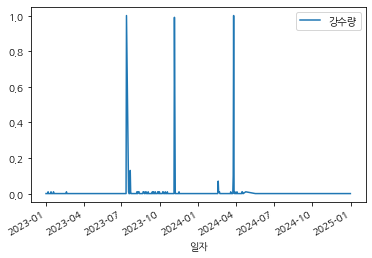

In [102]:
rain.plot(x='일자', y= '강수량')

#### (강수량) 보간 함수

In [ ]:
## 누락된 날짜 확인 뒤, 결측치 채우는 함수

def interpolate_data(df, plant_name):
    # 1. 사업소 데이터 추출
    plant_mask = (df['사업소'] == plant_name)
    df_plant = df.loc[plant_mask].copy()
    df_plant['일자'] = pd.to_datetime(df_plant['일자'], format='%Y%m%d')

    # 2. 전체 날짜 생성
    full_dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

    # 3. 누락된 날짜 보간을 위한 재인덱싱
    df_plant = df_plant.set_index('일자').reindex(full_dates)

    # 4. 고정 정보 입력
    df_plant['사업소'] = plant_name

    # 5. 시계열 기준 강수량 보간ㅁ
    for col in df_plant.columns:
        # 결측치가 있는 열만 처리
        if pd.api.types.is_numeric_dtype(df_plant[col]) and df_plant[col].isna().any():
            try:
                df_plant[col] = df_plant[col].interpolate(method='time')
            except Exception as e:
                print(f"보간 실패: {col} - {e}")


    # 6. 일자 컬럼 복원
    df_plant = df_plant.reset_index().rename(columns={'index': '일자'})

    return df_plant

In [ ]:
''' 
# 7. 원본 df에서 해당 사업소 행 제거
df = df[~(df['사업소'] == plant_name)]

# 9. 보간된 선재도 데이터 추가
df = pd.concat([df, df_plant], ignore_index=True)

# 10. 정렬
df = df.sort_values(by=['사업소', '호기', '일자']).reset_index(drop=True)
'''

#### 선재도 강수량 보간

In [224]:
# 1. 영흥 + 선재도 데이터 추출
sunjae_mask = (df4['사업소'] == '영흥') & (df4['호기'] == '선재도')
df_sunjae = df4.loc[sunjae_mask].copy()
df_sunjae['일자'] = pd.to_datetime(df_sunjae['일자'], format='%Y%m%d')

# 2. 전체 날짜 생성
full_dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')

# 3. 누락된 날짜 보간을 위한 재인덱싱
df_sunjae = df_sunjae.set_index('일자').reindex(full_dates)

# 4. 고정 정보 입력
df_sunjae['사업소'] = '영흥'
df_sunjae['호기'] = '선재도'

# 5. 강수량 보간
df_sunjae['강수량'] = df_sunjae['강수량'].interpolate(method='time')

# 6. 일자 컬럼 복원
df_sunjae = df_sunjae.reset_index().rename(columns={'index': '일자'})

# 7. 원본 df에서 영흥 + 선재도 행 제거
df4 = df4[~(df4['사업소'] == '영흥')]

# 9. 보간된 선재도 데이터 추가
df4 = pd.concat([df4, df_sunjae], ignore_index=True)

# 10. 정렬
df4 = df4.sort_values(by=['사업소', '호기', '일자']).reset_index(drop=True)


### 영흥 결측치 처리 완료
df4[df4['사업소'] == '영흥'].head()

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
2000,영흥,선재도,2023-01-01,-1.60,45.82,354.17,4.64,0.0,NaN,-1.60,45.82,354.17,4.64,0.0,NaN
2001,영흥,선재도,2023-01-02,-3.22,60.37,355.43,3.33,0.0,NaN,-3.22,60.37,355.43,3.33,0.0,NaN
2002,영흥,선재도,2023-01-03,-1.48,51.30,188.72,1.19,0.0,NaN,-1.48,51.30,188.72,1.19,0.0,NaN
2003,영흥,선재도,2023-01-04,0.15,72.31,88.26,0.83,0.0,NaN,0.15,72.31,88.26,0.83,0.0,NaN
2004,영흥,선재도,2023-01-05,1.11,90.44,96.00,0.06,0.0,NaN,1.11,90.44,96.00,0.06,0.0,NaN


In [225]:
## 보간 잘되었는지 확인
df4[df4['사업소'] == '영흥']['강수량'].count()

731

In [226]:
df4[df4['사업소'] == '영흥']['강수량'].isnull().sum()

0

In [245]:
df4[df4['사업소'] == '영흥'].count()

사업소       731
호기        731
일자        731
온도        598
습도        598
풍향        598
풍속        598
강수량       731
기압          0
대기안정도     598
증발량       598
일조시간      598
전일강수량     598
60분강수량    598
금일강수량       0
dtype: int64

#### 전일 강수량 그래프 (영흥)

<ipython-input-91-66e5585aaa5f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain['일자'] = pd.to_datetime(rain['일자'], format='%Y%m%d')


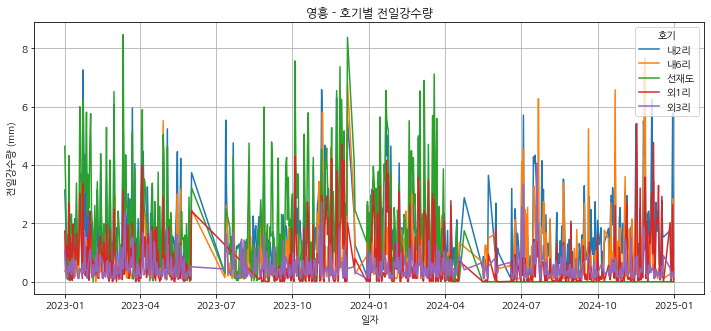

In [91]:
# 영흥 강수량 데이터 - 선재도(호기명)에만 있음
rain = df4[(df4['사업소'] == '영흥')& (df4['전일강수량'].notna())]
rain['일자'] = pd.to_datetime(rain['일자'], format='%Y%m%d')

plt.figure(figsize=(12, 5))
sns.lineplot(data=rain, x='일자', y='전일강수량', hue='호기')

plt.title('영흥 - 호기별 전일강수량')
plt.ylabel('전일강수량 (mm)')
plt.grid(True)
plt.legend(title='호기')
plt.show()


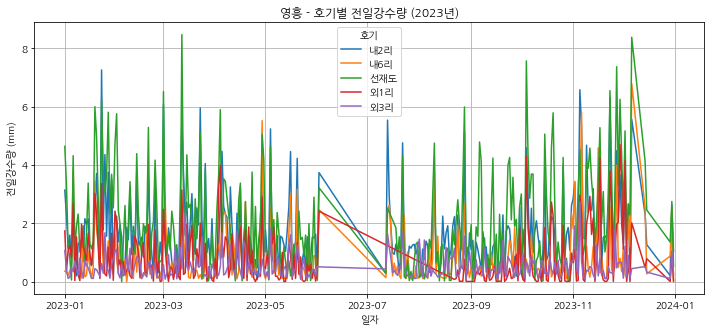

In [92]:
mask = (rain['일자'] >= '2023-01-01') & (rain['일자'] <= '2023-12-31')
rain_1y = rain.loc[mask] 

plt.figure(figsize=(12, 5))
sns.lineplot(data=rain_1y, x='일자', y='전일강수량', hue='호기')


plt.title('영흥 - 호기별 전일강수량 (2023년)')
plt.ylim()
plt.ylabel('전일강수량 (mm)')
plt.grid(True)
plt.legend(title='호기')
plt.show()

In [ ]:
# 영흥 강수량 데이터 - 선재도(호기명)에만 있음
df4[(df4['사업소'] == '영흥')& (df4['강수량'].notna())]['호기'].unique()

array(['선재도'], dtype=object)

### 삼천포, 영동 강수량 데이터 보간
- 분당은 데이터 전체가 null이므로 마지막에 보간

In [227]:
missing_date(df4)

    지역  누락일자수                                               누락일자
0   분당      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
1  삼천포    128  DatetimeIndex(['2023-02-17', '2023-02-18', '20...
2   영동     62  DatetimeIndex(['2023-01-30', '2023-06-06', '20...


- 삼천포

In [229]:
df4[(df4['사업소'] == '삼천포') & (df4['강수량'].isnull())]

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량


In [230]:
df_samcheonpo = interpolate_rain(df4, '삼천포')
missing_date(df_samcheonpo)

Empty DataFrame
Columns: []
Index: []


In [232]:
df_samcheonpo['강수량'].isnull().sum()

0

In [233]:
df_samcheonpo.count()

일자        731
사업소       731
호기        603
온도        603
습도        603
풍향        603
풍속        603
강수량       731
기압          0
대기안정도     603
증발량       603
일조시간      603
전일강수량     603
60분강수량    603
금일강수량       0
dtype: int64

- 영동

In [234]:
df4[(df4['사업소'] == '영동') & (df4['강수량'].isnull())]

,사업소,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
1341,영동,-,2023-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [235]:
df_yd = interpolate_rain(df4, '영동')
missing_date(df_yd)

Empty DataFrame
Columns: []
Index: []


In [ ]:
df_yd['강수량'].isnull().sum()

0

In [237]:
df_yd.count()

일자        731
사업소       731
호기        669
온도        668
습도        668
풍향        668
풍속        668
강수량       731
기압        668
대기안정도     668
증발량       668
일조시간      668
전일강수량     668
60분강수량    668
금일강수량     668
dtype: int64

### 보간 데이터 합치기

In [238]:
# 7. 원본 df에서 해당 사업소 행 제거
df_final = df4.copy()
df_final = df_final[~(df_final['사업소'] == '삼천포')]
df_final = df_final[~(df_final['사업소'] == '영동')]

# 9. 보간된 선재도 데이터 추가
df_final = pd.concat([df_final, df_samcheonpo, df_yd], ignore_index=True)

# 10. 정렬
df_final = df_final.sort_values(by=['사업소', '호기', '일자']).reset_index(drop=True)

In [243]:
df_final.groupby('사업소').count()

,호기,일자,온도,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
사업소,,,,,,,,,,,,,,
분당,728,728,728,728,728,728,0,0,728,728,728,728,0,0
삼천포,603,731,603,603,603,603,731,0,603,603,603,603,603,0
영동,669,731,668,668,668,668,731,668,668,668,668,668,668,668
영흥,731,731,598,598,598,598,731,0,598,598,598,598,598,0


## 전처리 후 데이터

In [4]:
df1.head(3)

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.960,46.07,325.03,1.51,0.0,NaN,-3.960,46.07,325.03,1.51,NaN,NaN
1,영흥,2023-01-01,-2.118,39.24,268.83,2.19,0.0,NaN,-2.118,39.24,268.83,2.19,0.0,NaN
2,삼천포,2023-01-01,2.630,41.55,202.97,2.49,0.0,NaN,2.630,41.55,202.97,2.49,0.0,NaN


In [8]:
df1.groupby('사업소').count()

,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
사업소,,,,,,,,,,,,,
분당,728,728,728,728,728,728,0,728,728,728,728,0,0
삼천포,603,603,603,603,603,603,0,603,603,603,603,603,0
여수,731,731,731,731,731,731,731,0,0,0,0,0,729
영동,669,669,669,669,669,669,668,668,668,668,668,668,668
영흥,610,610,610,610,610,610,0,610,610,610,610,598,0


In [14]:
import pandas as pd

# 일자 컬럼이 datetime 형식인지 확인하고 변환
df = df1.copy()
df['일자'] = pd.to_datetime(df['일자'])

# 결과 저장용 리스트
missing_date_info = []

# 사업소 + 호기 조합별로 그룹화
for (plant), group in df.groupby('사업소'):
    # 일자 기준 정렬
    group = group.sort_values('일자')

    # 전체 날짜 범위 생성 (빈 날짜 포함)
    full_range = pd.date_range(start=group['일자'].min(), end=group['일자'].max(), freq='D')

    # 누락된 날짜 확인
    missing_dates = full_range.difference(group['일자'])

    if len(missing_dates) > 0:
        missing_date_info.append({
            '지역': plant,
            '누락일자수': len(missing_dates),
            '누락일자': missing_dates
        })

# 결과 DataFrame으로 변환
missing_df = pd.DataFrame(missing_date_info)

print(missing_df)


    지역  누락일자수                                               누락일자
0   분당      3  DatetimeIndex(['2023-12-13', '2023-12-14', '20...
1  삼천포     71  DatetimeIndex(['2023-02-17', '2023-02-18', '20...
2   영동     62  DatetimeIndex(['2023-01-30', '2023-06-06', '20...
3   영흥    121  DatetimeIndex(['2023-01-21', '2023-06-03', '20...


In [5]:
df2.head(3)

,사업소,호기,일자,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,연도,월,new_호기,호기구분
0,경상대태양광,1,2024-12-01,0.91,78.62,0.0,11.61,태양력,기타,2024,12,1,NaN
1,고흥만 수상태양광,1,2024-12-01,63.48,6026.18,0.0,12.76,태양력,기타,2024,12,1,NaN
2,광양항세방태양광,1,2024-12-01,3.10,204.02,0.0,8.85,태양력,기타,2024,12,1,NaN


In [57]:
df2['일자'].value_counts()
# 연월별 컬럼 생성
df2['연월'] = pd.to_datetime(df2['일자']).dt.strftime('%Y-%m')

In [58]:
df2.head(3)

,사업소,호기,일자,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,연도,월,new_호기,호기구분,연월
0,경상대태양광,1,2024-12-01,0.91,78.62,0.0,11.61,태양력,기타,2024,12,1,NaN,2024-12
1,고흥만 수상태양광,1,2024-12-01,63.48,6026.18,0.0,12.76,태양력,기타,2024,12,1,NaN,2024-12
2,광양항세방태양광,1,2024-12-01,3.10,204.02,0.0,8.85,태양력,기타,2024,12,1,NaN,2024-12


In [59]:
df2.drop(['연도','월'],axis=1,inplace=True)

In [60]:
df2.head(3)

,사업소,호기,일자,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,new_호기,호기구분,연월
0,경상대태양광,1,2024-12-01,0.91,78.62,0.0,11.61,태양력,기타,1,NaN,2024-12
1,고흥만 수상태양광,1,2024-12-01,63.48,6026.18,0.0,12.76,태양력,기타,1,NaN,2024-12
2,광양항세방태양광,1,2024-12-01,3.10,204.02,0.0,8.85,태양력,기타,1,NaN,2024-12


In [61]:
df2.drop(['사업소','호기','일자'],axis=1,inplace=True)

In [62]:
df2.head()

,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,new_호기,호기구분,연월
0,0.91,78.62,0.0,11.61,태양력,기타,1,NaN,2024-12
1,63.48,6026.18,0.0,12.76,태양력,기타,1,NaN,2024-12
2,3.10,204.02,0.0,8.85,태양력,기타,1,NaN,2024-12
3,0.99,94.24,0.0,12.79,태양력,기타,1,NaN,2024-12
4,11.55,3323.39,0.0,38.67,알수없음,기타,1,NaN,2024-12


In [63]:
df2=df2[df2['지역']!='기타']
df2.shape

(1268, 9)

In [64]:
df2.head()

,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,new_호기,호기구분,연월
6,77.76,52698.0,30.85,91.09,복합,분당,1,CG,2024-12
7,77.76,26642.0,30.50,46.05,복합,분당,2,CG,2024-12
8,77.76,63329.0,31.96,109.46,복합,분당,3,CG,2024-12
9,77.76,2407.0,31.10,4.16,복합,분당,4,CG,2024-12
10,77.76,38057.0,21.41,65.78,복합,분당,5,CG,2024-12


In [65]:
df2.to_csv('./발전실적_전처리후2.csv',index=False)

In [66]:
df2.isna().sum()

용량(MW)        0
발전량(MWh)      0
열효율(%)        0
이용률(%)        0
발전원           0
지역            0
new_호기        0
호기구분        980
연월            0
dtype: int64

In [67]:
df3.head(3)

,사업소,호기,일자,SOX,NOX,먼지,산소,유량,온도,연도,월,일,날짜,new_호기,호기구분,연월
0,분당,1호기,20241231,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,31,2024-12-31,1,NaN,2024-12
1,분당,2호기,20241231,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,31,2024-12-31,2,NaN,2024-12
2,분당,3호기,20241231,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,31,2024-12-31,3,NaN,2024-12


In [68]:
df1.head()

,사업소,일자,기온,습도,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,2023-01-01,-3.960,46.070,325.03,1.51,0.0,NaN,-3.960,46.07,325.03,1.51,NaN,NaN
1,영흥,2023-01-01,-2.118,39.240,268.83,2.19,0.0,NaN,-2.118,39.24,268.83,2.19,0.0,NaN
2,삼천포,2023-01-01,2.630,41.550,202.97,2.49,0.0,NaN,2.630,41.55,202.97,2.49,0.0,NaN
3,여수,2023-01-01,4.700,51.875,277.80,5.40,0.0,1019.841667,NaN,NaN,NaN,NaN,NaN,0.00
4,영동,2023-01-01,2.080,17.910,277.07,5.90,0.0,1024.430000,2.080,17.91,277.07,5.90,0.0,1024.43


In [69]:
df3.head()

,사업소,호기,일자,SOX,NOX,먼지,산소,유량,온도,연도,월,일,날짜,new_호기,호기구분,연월
0,분당,1호기,20241231,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,31,2024-12-31,1,NaN,2024-12
1,분당,2호기,20241231,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,31,2024-12-31,2,NaN,2024-12
2,분당,3호기,20241231,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,31,2024-12-31,3,NaN,2024-12
3,분당,4호기,20241231,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,31,2024-12-31,4,NaN,2024-12
4,분당,5호기,20241231,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,31,2024-12-31,5,NaN,2024-12


In [70]:
df3.drop(['일자'],axis=1,inplace=True)

In [71]:
df3.rename(columns={'날짜':'일자'},inplace=True)

In [72]:
merged_df = pd.merge(df3, df1, on=['사업소', '일자'], how='inner')


In [73]:
merged_df.head()

,사업소,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
2,분당,3호기,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
3,분당,4호기,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
4,분당,5호기,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN


In [74]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17036 entries, 0 to 17035
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   사업소     17036 non-null  object 
 1   호기      17036 non-null  object 
 2   SOX     11215 non-null  float64
 3   NOX     17036 non-null  float64
 4   먼지      11215 non-null  float64
 5   산소      17036 non-null  float64
 6   유량      17035 non-null  float64
 7   온도      17036 non-null  float64
 8   연도      17036 non-null  int64  
 9   월       17036 non-null  int64  
 10  일       17036 non-null  int64  
 11  일자      17036 non-null  object 
 12  new_호기  17036 non-null  int64  
 13  호기구분    4755 non-null   object 
 14  연월      17036 non-null  object 
 15  기온      17036 non-null  float64
 16  습도      17036 non-null  float64
 17  풍향      17036 non-null  float64
 18  풍속      17036 non-null  float64
 19  강수량     17036 non-null  float64
 20  기압      2798 non-null   float64
 21  대기안정도   15572 non-null  float64
 22

In [75]:
merged_df['연월']

0        2024-12
1        2024-12
2        2024-12
3        2024-12
4        2024-12
          ...   
17031    2023-01
17032    2023-01
17033    2023-01
17034    2023-01
17035    2023-01
Name: 연월, Length: 17036, dtype: object

In [76]:
merged_df.columns

Index(['사업소', '호기', 'SOX', 'NOX', '먼지', '산소', '유량', '온도', '연도', '월', '일', '일자',
       'new_호기', '호기구분', '연월', '기온', '습도', '풍향', '풍속', '강수량', '기압', '대기안정도',
       '증발량', '일조시간', '전일강수량', '60분강수량', '금일강수량'],
      dtype='object')

In [77]:
merged_df.to_csv('./merged_df.csv',index=False)

In [78]:
merged_df.shape

(17036, 27)

In [79]:
merged_df.head()

,사업소,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
2,분당,3호기,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
3,분당,4호기,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
4,분당,5호기,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN


In [80]:
merged_df[['일자']].head(50)

,일자
0,2024-12-31
1,2024-12-31
2,2024-12-31
3,2024-12-31
4,2024-12-31
5,2024-12-31
6,2024-12-31
7,2024-12-31
8,2024-12-31
9,2024-12-31


In [81]:
merged_df.shape

(17036, 27)

In [82]:
merged_df.head()

,사업소,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
2,분당,3호기,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
3,분당,4호기,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
4,분당,5호기,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN


In [83]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17036 entries, 0 to 17035
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   사업소     17036 non-null  object 
 1   호기      17036 non-null  object 
 2   SOX     11215 non-null  float64
 3   NOX     17036 non-null  float64
 4   먼지      11215 non-null  float64
 5   산소      17036 non-null  float64
 6   유량      17035 non-null  float64
 7   온도      17036 non-null  float64
 8   연도      17036 non-null  int64  
 9   월       17036 non-null  int64  
 10  일       17036 non-null  int64  
 11  일자      17036 non-null  object 
 12  new_호기  17036 non-null  int64  
 13  호기구분    4755 non-null   object 
 14  연월      17036 non-null  object 
 15  기온      17036 non-null  float64
 16  습도      17036 non-null  float64
 17  풍향      17036 non-null  float64
 18  풍속      17036 non-null  float64
 19  강수량     17036 non-null  float64
 20  기압      2798 non-null   float64
 21  대기안정도   15572 non-null  float64
 22

In [84]:
merged_df.columns

Index(['사업소', '호기', 'SOX', 'NOX', '먼지', '산소', '유량', '온도', '연도', '월', '일', '일자',
       'new_호기', '호기구분', '연월', '기온', '습도', '풍향', '풍속', '강수량', '기압', '대기안정도',
       '증발량', '일조시간', '전일강수량', '60분강수량', '금일강수량'],
      dtype='object')

In [85]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17036 entries, 0 to 17035
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   사업소     17036 non-null  object 
 1   호기      17036 non-null  object 
 2   SOX     11215 non-null  float64
 3   NOX     17036 non-null  float64
 4   먼지      11215 non-null  float64
 5   산소      17036 non-null  float64
 6   유량      17035 non-null  float64
 7   온도      17036 non-null  float64
 8   연도      17036 non-null  int64  
 9   월       17036 non-null  int64  
 10  일       17036 non-null  int64  
 11  일자      17036 non-null  object 
 12  new_호기  17036 non-null  int64  
 13  호기구분    4755 non-null   object 
 14  연월      17036 non-null  object 
 15  기온      17036 non-null  float64
 16  습도      17036 non-null  float64
 17  풍향      17036 non-null  float64
 18  풍속      17036 non-null  float64
 19  강수량     17036 non-null  float64
 20  기압      2798 non-null   float64
 21  대기안정도   15572 non-null  float64
 22

In [86]:
#df2.drop('일자',axis=1,inplace=True)
#df2.head()

In [87]:
df2.drop('호기구분',axis=1,inplace=True)
df2.head(3)

,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,new_호기,연월
6,77.76,52698.0,30.85,91.09,복합,분당,1,2024-12
7,77.76,26642.0,30.50,46.05,복합,분당,2,2024-12
8,77.76,63329.0,31.96,109.46,복합,분당,3,2024-12


In [88]:
df2.shape

(1268, 8)

In [89]:
df2=df2[df2['지역']!='기타']
df2.shape

(1268, 8)

In [90]:
merged_df.head(2)

,사업소,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,풍향,풍속,강수량,기압,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,333.13,2.52,0.0,NaN,-3.77,66.45,333.13,2.52,NaN,NaN


In [91]:
merged_df.rename(columns={'사업소':'지역'},inplace=True)

In [92]:
df2.head()

,용량(MW),발전량(MWh),열효율(%),이용률(%),발전원,지역,new_호기,연월
6,77.76,52698.0,30.85,91.09,복합,분당,1,2024-12
7,77.76,26642.0,30.50,46.05,복합,분당,2,2024-12
8,77.76,63329.0,31.96,109.46,복합,분당,3,2024-12
9,77.76,2407.0,31.10,4.16,복합,분당,4,2024-12
10,77.76,38057.0,21.41,65.78,복합,분당,5,2024-12


In [93]:
# 'df'가 정의되어 있지 않으므로, df2에서 '일자' 컬럼을 사용하여 '연월' 컬럼을 생성합니다.
df2['연월'].head()

6     2024-12
7     2024-12
8     2024-12
9     2024-12
10    2024-12
Name: 연월, dtype: object

In [94]:
# df2 ['지역', 'new_호기', '연월'] 평균값 내야됨

df2_grouped_mean = df2.groupby(['지역', 'new_호기', '연월']).mean(numeric_only=True).reset_index()
df2_grouped_mean.head()

,지역,new_호기,연월,용량(MW),발전량(MWh),열효율(%),이용률(%)
0,분당,1,2023-01,131.38,59496.0,14.215,70.540
1,분당,1,2023-02,131.38,53299.5,14.090,73.030
2,분당,1,2023-03,131.38,22260.5,13.995,21.565
3,분당,1,2023-04,131.38,1693.0,12.585,2.205
4,분당,1,2023-05,131.38,2274.0,10.465,3.090


In [95]:
merged_df['연월'] = pd.to_datetime(merged_df['일자']).dt.strftime('%Y-%m')

# 발전실적 데이터 재불러오기 (utf-8-sig 인코딩 사용)
#generation_df = pd.read_csv("./발전실적_전처리후2.csv", encoding='utf-8-sig')

# 공통 키 정리
merged_df['new_호기'] = merged_df['new_호기'].astype(str)
df2_grouped_mean['new_호기'] = df2_grouped_mean['new_호기'].astype(str)

merged_df['연월'] = merged_df['연월'].astype(str)
df2_grouped_mean['연월'] = df2_grouped_mean['연월'].astype(str)

# merged_df_latest_clean = merged_df.drop(columns=['호기구분'])

# 병합 수행 (left join)
final_df_clean = pd.merge(
    merged_df,
    df2_grouped_mean,
    on=['지역', 'new_호기', '연월'],
    how='left'
)


In [96]:
final_df_clean.head()

,지역,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량,용량(MW),발전량(MWh),열효율(%),이용률(%)
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,131.38,51906.000,15.425000,64.115000
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,65.28,23784.230,20.446667,43.323333
2,분당,3호기,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,41.74,33236.040,32.230000,91.660000
3,분당,4호기,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,47.24,5890.170,31.580000,39.755000
4,분당,5호기,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,41.74,20747.425,27.215000,73.280000


In [97]:
final_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17036 entries, 0 to 17035
Data columns (total 31 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지역        17036 non-null  object 
 1   호기        17036 non-null  object 
 2   SOX       11215 non-null  float64
 3   NOX       17036 non-null  float64
 4   먼지        11215 non-null  float64
 5   산소        17036 non-null  float64
 6   유량        17035 non-null  float64
 7   온도        17036 non-null  float64
 8   연도        17036 non-null  int64  
 9   월         17036 non-null  int64  
 10  일         17036 non-null  int64  
 11  일자        17036 non-null  object 
 12  new_호기    17036 non-null  object 
 13  호기구분      4755 non-null   object 
 14  연월        17036 non-null  object 
 15  기온        17036 non-null  float64
 16  습도        17036 non-null  float64
 17  풍향        17036 non-null  float64
 18  풍속        17036 non-null  float64
 19  강수량       17036 non-null  float64
 20  기압        2798 non-null   fl

In [98]:
final_df_clean.shape

(17036, 31)

In [99]:
final_df_clean.isna().sum()

지역              0
호기              0
SOX          5821
NOX             0
먼지           5821
산소              0
유량              1
온도              0
연도              0
월               0
일               0
일자              0
new_호기          0
호기구분        12281
연월              0
기온              0
습도              0
풍향              0
풍속              0
강수량             0
기압          14238
대기안정도        1464
증발량          1464
일조시간         1464
전일강수량        1464
60분강수량       7357
금일강수량       14242
용량(MW)          0
발전량(MWh)        0
열효율(%)          0
이용률(%)          0
dtype: int64

In [100]:
final_df_clean.head()

,지역,호기,SOX,NOX,먼지,산소,유량,온도,연도,월,...,대기안정도,증발량,일조시간,전일강수량,60분강수량,금일강수량,용량(MW),발전량(MWh),열효율(%),이용률(%)
0,분당,1호기,NaN,6.76,NaN,15.38,52558.65,124.67,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,131.38,51906.000,15.425000,64.115000
1,분당,2호기,NaN,3.86,NaN,20.90,82.73,16.32,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,65.28,23784.230,20.446667,43.323333
2,분당,3호기,NaN,8.07,NaN,15.22,69124.62,123.12,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,41.74,33236.040,32.230000,91.660000
3,분당,4호기,NaN,3.47,NaN,20.85,109.42,20.09,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,47.24,5890.170,31.580000,39.755000
4,분당,5호기,NaN,8.09,NaN,15.66,82712.37,108.17,2024,12,...,-3.77,66.45,333.13,2.52,NaN,NaN,41.74,20747.425,27.215000,73.280000


In [101]:
final_df_clean.to_csv('./final_series_df.csv',index=False)